# PlantMetWiki figures

Publication-quality figures for the PlantMetWiki paper.

---

## How to run

**Step 1 — generate data from Virtuoso** (run once per data version, ~30 sec):
```bash
conda activate plantmetwiki-rdf

# Make sure Virtuoso is running
# (cd to Snorql-UI: docker compose up -d virtuoso)

# Query Virtuoso and write CSVs to notebooks/figures/output/
python scripts/generate_figures_data.py

# Skip slow per-species query for quick iteration
python scripts/generate_figures_data.py --skip-species
```

**Step 2 — run this notebook** (loads CSVs, produces figures):
```
Kernel → Restart & Run All
```

Figures are saved to **`figures/output/figures/`** as `.pdf` and `.svg`.

---

## Architecture

```
Virtuoso (graph/pathways + graph/gpml-taxonomy-extra + graph/ncbitaxon)
    │
    ▼  scripts/generate_figures_data.py   (queries via SPARQLWrapper)
notebooks/figures/output/*.csv            ← committed to git
    │
    ▼  this notebook
notebooks/figures/output/figures/*.pdf/.svg
```

The CSVs are committed to git so **this notebook runs without Virtuoso**.
Only re-run `generate_figures_data.py` when the underlying data changes.

---

## Named graphs queried

| CSV | Graph(s) |
|---|---|
| `genes/metabolites/enzymes/conversions_per_pathway.csv` | `graph/pathways` |
| `interaction_types.csv` | `graph/pathways` |
| `pathway_titles.csv` | `graph/pathways` |
| `species_per_pathway.csv` | `graph/pathways` + `graph/gpml-taxonomy-extra` |
| `per_species_nrs.csv` | all three + `graph/ncbitaxon` (species labels) |

**Kernel:** `plantmetwiki-rdf`

---

## SPARQL endpoint

You can run every query in this notebook against **either** endpoint:

| Mode | URL | When to use |
|------|-----|-------------|
| **Public** (no setup needed) | `https://plantmetwiki.bioinformatics.nl/sparql` | Quickest way to get started; no local installation required |
| **Local Virtuoso** (full data, fast) | `http://localhost:8890/sparql` | Required for the figures notebook (large aggregations); needs Docker |

To switch, change the `ENDPOINT` variable in the setup cell below.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ── Paths ─────────────────────────────────────────────────────────────────────
OUT_DIR  = Path('figures/output')
FIG_DIR  = OUT_DIR / 'figures'   # PDF/SVG outputs go here
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'font.family': 'sans-serif',
                     'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans']})

# ── Load pre-computed CSVs ────────────────────────────────────────────────────
def load(name):
    path = OUT_DIR / name
    assert path.exists(), f'Missing: {path}\nRun: python scripts/generate_figures_data.py'
    return pd.read_csv(path)

def save_fig(fig, name):
    for ext in ('pdf', 'svg'):
        fig.savefig(FIG_DIR / f'{name}.{ext}', bbox_inches='tight')
    print(f'  Saved -> {FIG_DIR}/{name}.{{pdf,svg}}')

WP_INTERACTION = 'http://vocabularies.wikipathways.org/wp#Interaction'

print('Loading CSVs ...')
genes       = load('genes_per_pathway.csv')
metabolites = load('metabolites_per_pathway.csv')
enzymes     = load('enzymes_per_pathway.csv')
conversions = load('conversions_per_pathway.csv')
int_types   = load('interaction_types.csv')
per_species = load('per_species_nrs.csv')
species_pw  = load('species_per_pathway.csv')
titles      = load('pathway_titles.csv')
ann         = load('annotation_summary.csv').set_index('entity')

# True *unique* entity totals (no double-counting across pathways) and the
# precomputed true-unique cumulative-coverage curves -- see
# scripts/generate_figures_data.py::entity_totals / cumulative_coverage.
entity_totals = load('entity_totals.csv').set_index('entity')['count']
cum_cov       = load('cumulative_coverage.csv')

print(f'  pathways: {len(titles):,}  |  genes: {len(genes):,}  |  species: {len(per_species):,}')
print(f"  Unique totals -> genes: {entity_totals['Genes']:,}  enzymes: {entity_totals['Enzymes']:,}  "
      f"metabolites: {entity_totals['Metabolites']:,}  complexes: {entity_totals['Complexes']:,}  "
      f"catalysis: {entity_totals['Catalysis']:,}")
print(f'  Figures will be saved to: {FIG_DIR.resolve()}')


Loading CSVs ...
  pathways: 2,478  |  genes: 1,484  |  species: 320
  Unique totals -> genes: 2,758  enzymes: 3,750  metabolites: 4,577  complexes: 70  catalysis: 12,359
  Figures will be saved to: /Users/elenadelpup/Library/CloudStorage/OneDrive-WageningenUniversity&Research/PhD/software/plantwiki/gpml-to-rdf/notebooks/figures/output/figures


---
## 2. Normalize

In [2]:
def norm(df, count_col, count_name):
    df = df.copy()
    df = df.rename(columns={count_col: count_name})
    df[count_name] = pd.to_numeric(df[count_name], errors="coerce").fillna(0)
    if "pwID" in df.columns:
        df["pwID"] = df["pwID"].astype(str)
    return df

genes       = norm(genes,       "count", "genes")
metabolites = norm(metabolites, "count", "metabolites")
enzymes     = norm(enzymes,     "count", "enzymes")
conversions = norm(conversions, "count", "conversions")
species_pw  = norm(species_pw,  "count", "species")

int_types["n"] = pd.to_numeric(int_types["n"], errors="coerce").fillna(0).astype(int)
WP_INTERACTION = "http://vocabularies.wikipathways.org/wp#Interaction"
total_interactions = int(int_types.loc[int_types["type"] == WP_INTERACTION, "n"].iloc[0])

print("✅ Data ready")
print(f"  Pathways with gene data:       {len(genes):,}")
print(f"  Pathways with metabolite data: {len(metabolites):,}")
print(f"  Total interactions:            {total_interactions:,}")
print(f"  Species in per-species table:  {len(per_species):,}")

✅ Data ready
  Pathways with gene data:       1,484
  Pathways with metabolite data: 2,462
  Total interactions:            54,800
  Species in per-species table:  320


---
## 3. Figure: Overview bar chart (log scale)

### How pathway and reaction counts are calculated

PlantMetWiki contains two types of GPML-derived objects loaded together into `graph/pathways`:

| Type | IRI pattern | Count |
|------|-------------|-------|
| **Multispecies plant pathways** | `.../pathways/PC*` | 1,162 |
| **Individual enzymatic reactions** | `.../pathways/RC*` | 1,316 |

Both are typed as `wp:Pathway` in the WikiPathways RDF model (the `gpml2rdf` Java converter assigns `wp:Pathway` to any GPML file, whether it is a multi-step pathway or a single reaction). They are distinguished only by their IRI prefix (`PC` vs `RC`), which we filter on in `pathway_titles.csv`.

### What was wrong in the previous calculation

The overview bar previously used `len(genes_per_pathway.csv)` = **1,484** as the pathway count. That CSV is generated by a query that counts pathways containing **at least one gene product** — it therefore excludes pathways with only metabolites or interactions (undercounting), and it includes both PC* *and* RC* entries (mixing pathways with reactions). The corrected figure uses `pathway_titles.csv` filtered by IRI prefix, giving the exact **1,162 pathways** and **1,316 reactions** that match the input GPML files.


  Saved -> figures/output/figures/plantmetwiki_overview_barlog.{pdf,svg}


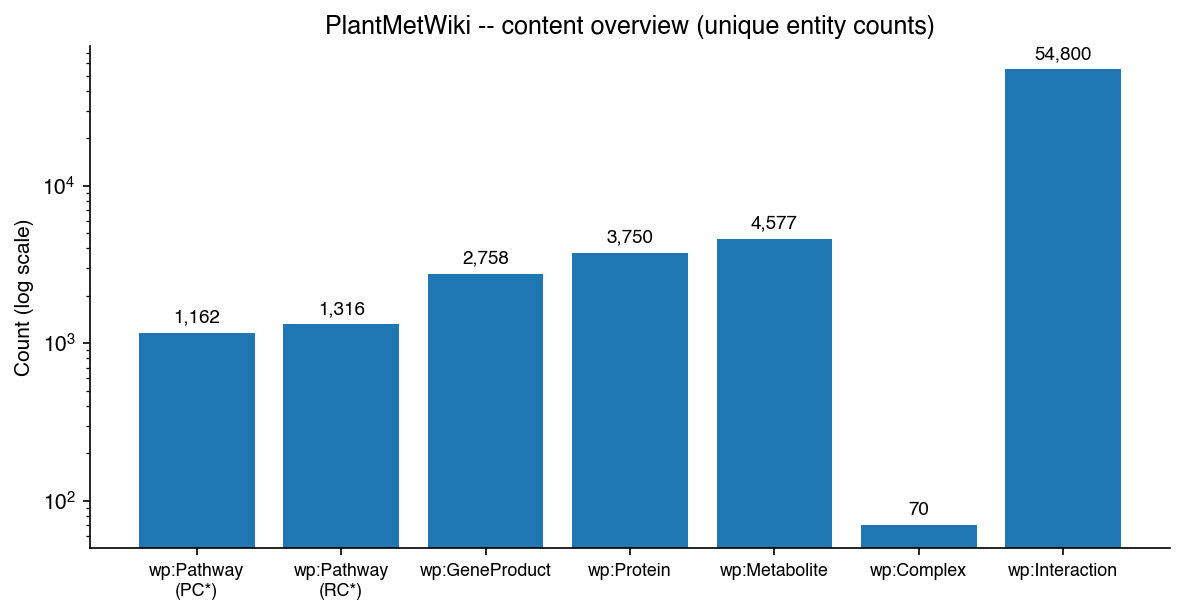

In [3]:
overview = {
    "wp:Pathway\n(PC*)":  int(entity_totals['Pathways']),
    "wp:Pathway\n(RC*)":  int(entity_totals['Reactions']),
    "wp:GeneProduct":      int(entity_totals['Genes']),
    "wp:Protein":          int(entity_totals['Enzymes']),
    "wp:Metabolite":       int(entity_totals['Metabolites']),
    "wp:Complex":          int(entity_totals['Complexes']),
    "wp:Interaction":      int(entity_totals['Interactions']),
}
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(list(overview.keys()), list(overview.values()))
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('PlantMetWiki -- content overview (unique entity counts)')
for bar, val in zip(bars, overview.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.1,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', labelsize=8.5)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'plantmetwiki_overview_barlog')
plt.show()


### Interpretation

This log-scale overview shows the size of PlantMetWiki across its five main content types.
The 1,162 **pathways** (PC\* IRIs) are curated multi-step metabolic maps; the 1,316 **reactions** (RC\* IRIs) are individual enzymatic steps — both are typed `wp:Pathway` by the `gpml2rdf` converter, so they are distinguished only by IRI prefix.
**Genes** and **Enzymes** are counted as distinct DataNode instances across all pathways (a gene appearing in five pathways is counted once per pathway in `genes_per_pathway.csv`, but here they are raw per-pathway sums; see Figure 3b for distinct-node counts).
**Metabolites** are the chemical compound nodes; **Interactions** are the typed edges (catalysis, conversion, binding, etc.).
The log scale is required because counts span 3–4 orders of magnitude.


> **Figure caption -- Overview bar chart.**
> Total **unique** counts of the main `wp:` content types in PlantMetWiki, on a logarithmic scale.
> Counts are true *distinct-entity* totals (`COUNT(DISTINCT ?e)` per class) -- an entity shared across several pathways is counted once here, unlike the per-pathway-summed tables used for the cumulative-coverage figure's denominators before this fix.
> **`wp:Pathway` (PC\*)** and **`wp:Pathway` (RC\*)**: pathways and reactions are both typed `wp:Pathway` by the `gpml2rdf` converter and are distinguished only by their IRI prefix.
> **`wp:GeneProduct`**, **`wp:Protein`**, **`wp:Metabolite`**, **`wp:Complex`**: DataNode entity types from the WikiPathways vocabulary (`http://vocabularies.wikipathways.org/wp#`).
> **`wp:Interaction`**: every instance of the parent interaction class (covers all typed edges: `wp:Conversion`, `wp:Catalysis`, `wp:TranscriptionTranslation`, `wp:Inhibition`, `wp:Stimulation`, `wp:Binding`, `wp:ComplexBinding`).


---
## 3b. Figure: Overview with species-annotation coverage

A variant of Figure 3 showing, for each entity type, how many nodes carry a **direct** `wp:organism` species annotation.
Direct annotations exist only on gene product and protein (enzyme) nodes, derived from the PlantCyc `proteins.dat` SPECIES field.
Metabolites are species-neutral in PlantCyc — their species context is inferred indirectly via shared-pathway co-occurrence (see Figures 6b and 7).


  Saved -> figures/output/figures/plantmetwiki_overview_annotated.{pdf,svg}


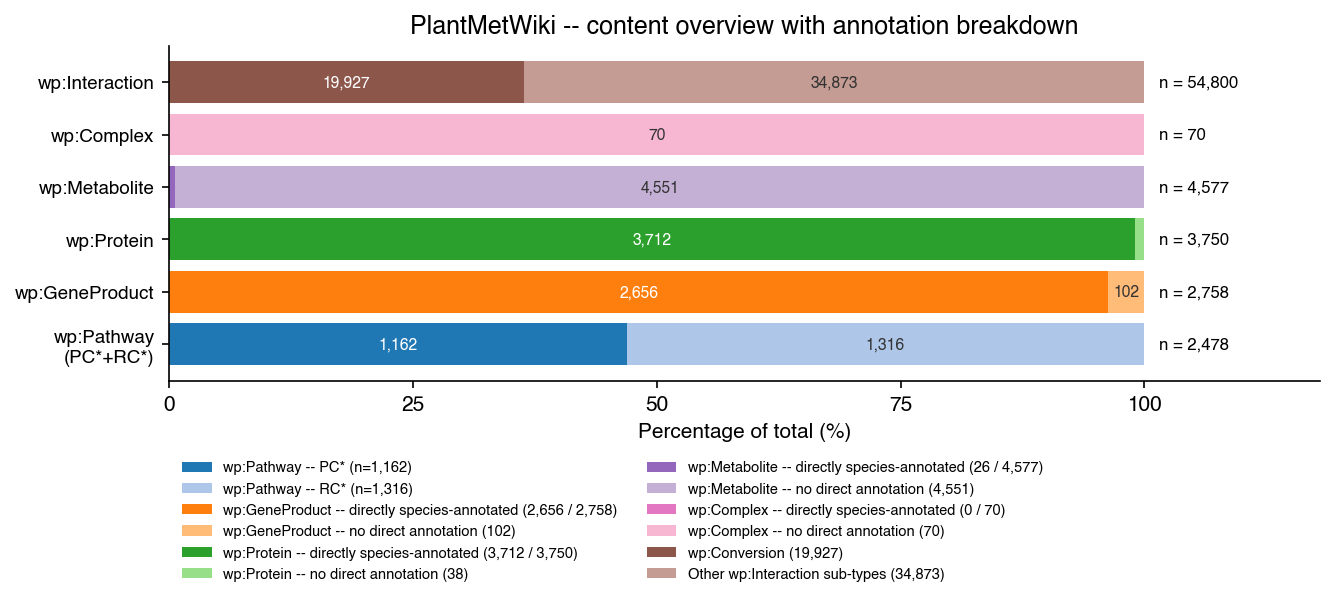

In [4]:
from matplotlib.patches import Patch

WP_CONVERSION  = 'http://vocabularies.wikipathways.org/wp#Conversion'
WP_INTERACTION = 'http://vocabularies.wikipathways.org/wp#Interaction'

n_pathways  = titles[titles['pwID'].str.contains('/PC')]['pwID'].nunique()
n_reactions = titles[titles['pwID'].str.contains('/RC')]['pwID'].nunique()

g_ann = int(ann.loc['genes',       'annotated']); g_tot = int(ann.loc['genes',       'total'])
e_ann = int(ann.loc['enzymes',     'annotated']); e_tot = int(ann.loc['enzymes',     'total'])
m_ann = int(ann.loc['metabolites', 'annotated']); m_tot = int(ann.loc['metabolites', 'total'])
c_ann = int(ann.loc['complexes',   'annotated']); c_tot = int(ann.loc['complexes',   'total'])

n_conv    = int(int_types.loc[int_types['type'] == WP_CONVERSION,  'n'].values[0])
n_tot_int = int(int_types.loc[int_types['type'] == WP_INTERACTION, 'n'].values[0])
n_other   = n_tot_int - n_conv

# category labels, primary (left) and secondary (right) absolute counts
cats    = ['wp:Pathway\n(PC*+RC*)', 'wp:GeneProduct', 'wp:Protein', 'wp:Metabolite', 'wp:Complex', 'wp:Interaction']
primary = [n_pathways,  g_ann,          e_ann,          m_ann,          c_ann,          n_conv ]
secondr = [n_reactions, g_tot - g_ann,  e_tot - e_ann,  m_tot - m_ann,  c_tot - c_ann,  n_other]
totals  = [p + s for p, s in zip(primary, secondr)]

# Normalize to 100 %
pct_p = [p / t * 100 for p, t in zip(primary, totals)]
pct_s = [s / t * 100 for s, t in zip(secondr, totals)]

C_PRI = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#e377c2', '#8c564b']
C_SEC = ['#aec7e8', '#ffbb78', '#98df8a', '#c5b0d5', '#f7b6d2', '#c49c94']

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(cats))

ax.barh(y, pct_p, color=C_PRI)
ax.barh(y, pct_s, left=pct_p, color=C_SEC)

# Annotate each segment with absolute count (skip if segment < 1 %)
for yi, (p, s, t, pp, ps) in enumerate(zip(primary, secondr, totals, pct_p, pct_s)):
    if pp >= 3:
        ax.text(pp / 2, yi, f'{p:,}', ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold')
    if ps >= 3:
        ax.text(pp + ps / 2, yi, f'{s:,}', ha='center', va='center',
                fontsize=7.5, color='#333')
    # Total on right
    ax.text(101.5, yi, f'n = {t:,}', va='center', fontsize=8)

ax.set_xlim(0, 118)
ax.set_xlabel('Percentage of total (%)')
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_yticks(y)
ax.set_yticklabels(cats, fontsize=9)
ax.set_title('PlantMetWiki -- content overview with annotation breakdown')

legend_handles = [
    Patch(facecolor='#1f77b4', label=f'wp:Pathway -- PC* (n={n_pathways:,})'),
    Patch(facecolor='#aec7e8', label=f'wp:Pathway -- RC* (n={n_reactions:,})'),
    Patch(facecolor='#ff7f0e', label=f'wp:GeneProduct -- directly species-annotated ({g_ann:,} / {g_tot:,})'),
    Patch(facecolor='#ffbb78', label=f'wp:GeneProduct -- no direct annotation ({g_tot-g_ann:,})'),
    Patch(facecolor='#2ca02c', label=f'wp:Protein -- directly species-annotated ({e_ann:,} / {e_tot:,})'),
    Patch(facecolor='#98df8a', label=f'wp:Protein -- no direct annotation ({e_tot-e_ann:,})'),
    Patch(facecolor='#9467bd', label=f'wp:Metabolite -- directly species-annotated ({m_ann:,} / {m_tot:,})'),
    Patch(facecolor='#c5b0d5', label=f'wp:Metabolite -- no direct annotation ({m_tot-m_ann:,})'),
    Patch(facecolor='#e377c2', label=f'wp:Complex -- directly species-annotated ({c_ann:,} / {c_tot:,})'),
    Patch(facecolor='#f7b6d2', label=f'wp:Complex -- no direct annotation ({c_tot-c_ann:,})'),
    Patch(facecolor='#8c564b', label=f'wp:Conversion ({n_conv:,})'),
    Patch(facecolor='#c49c94', label=f'Other wp:Interaction sub-types ({n_other:,})'),
]
ax.legend(handles=legend_handles, loc='upper left', frameon=False, fontsize=7,
          ncol=2, bbox_to_anchor=(0, -0.20))

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.46)
save_fig(fig, 'plantmetwiki_overview_annotated')
plt.show()


### Interpretation

For **genes** (2,758 total), 2,656 nodes (96 %) carry a direct `wp:organism` triple — the dark-orange segment.
The remaining ~4 % are gene nodes where PlantCyc did not record a resolvable species, or where the GPML annotation could not be mapped to an NCBITaxon IRI.

For **enzymes** (3,750 total), 3,712 nodes (99 %) are directly annotated — the compact light-green top segment is barely visible.

**Metabolites** (4,577 total) show a fully solid bar because there is no direct species annotation for compounds in the PlantCyc data model.
All metabolite–species associations in PlantMetWiki are therefore *indirect*: a metabolite is attributed to a species only when a gene of that species co-occurs in the same pathway (see Figures 6b and 7).

The stacked bar for Pathways+Reactions uses the same logic as Figure 3: the total bar height is 1,162 + 1,316 = 2,478 objects, split by IRI prefix.


### Interpretation

`wp:Complex` nodes (70 total) have **no** direct `wp:organism` annotation in this dataset (0 / 70) -- PlantCyc complexes are not individually species-tagged the way genes and enzymes are, so the whole bar shows as "no direct annotation."

> **Figure caption -- Annotation coverage overview.**
> Stacked horizontal bars: percentage of each `wp:` entity type with vs. without a direct `wp:organism` species annotation (`graph/gpml-taxonomy-extra`, excluding the Viridiplantae root `ncbi:33090`).
> `wp:Pathway` and `wp:Interaction` rows instead show their internal sub-type split (PC\*/RC\* IRIs; `wp:Conversion` vs. other `wp:Interaction` sub-types) since pathway/interaction nodes don't carry per-node species tags.
> Absolute counts (`n = ...`) are printed at the right edge of each row.


---
## 4. Figure: Cumulative coverage curves

  Saved -> figures/output/figures/plantmetwiki_cumulative_coverage.{pdf,svg}


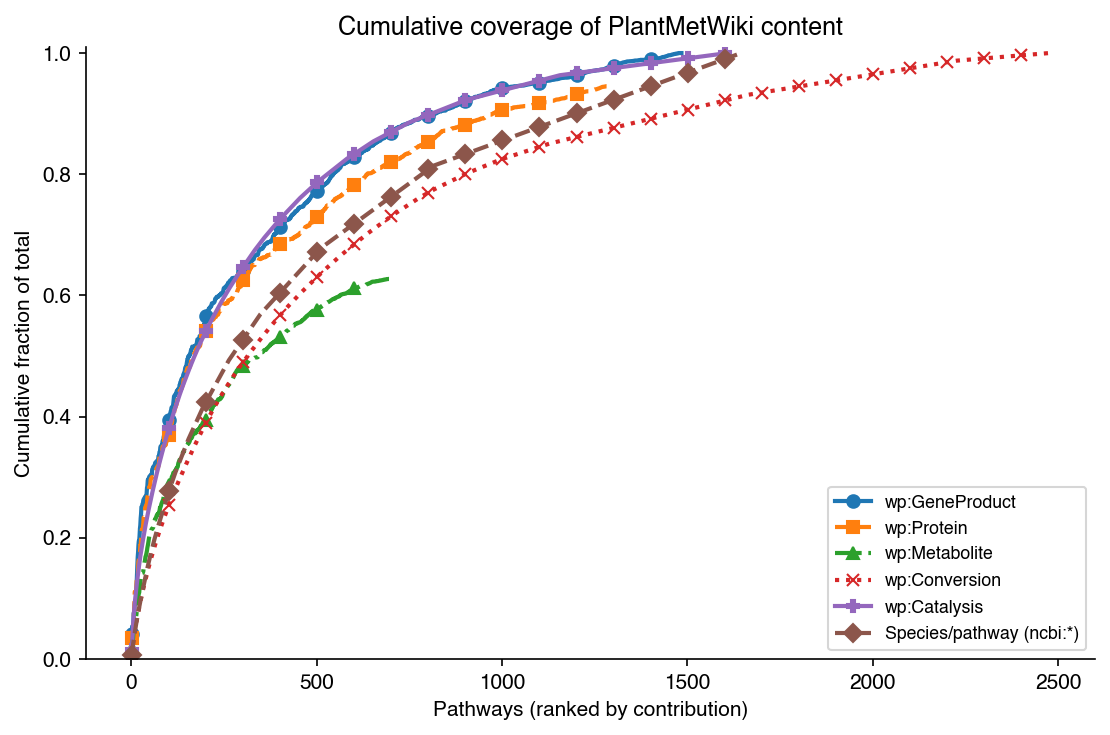

Metabolites: denominator = 4,577 unique wp:Metabolite nodes (curve reaches 62.7%)
Catalysis:   denominator = 12,359 unique wp:Catalysis nodes (curve reaches 100.0%)


In [5]:
# True unique-entity cumulative coverage, precomputed in
# scripts/generate_figures_data.py::cumulative_coverage (see Figure 3 caption
# for why genes/enzymes/metabolites need union-of-sets accumulation while
# conversions/catalysis don't).
pivot = cum_cov.pivot(index='rank', columns='metric', values='cumulative_fraction')

# Species/pathway is a per-pathway *diversity* metric (how many distinct
# species touch each pathway), not a fixed global entity pool, so it keeps
# its own simple per-pathway-sum normalisation -- see caption below.
def cumulative_curve(df, col):
    s = df[col].sort_values(ascending=False)
    total = s.sum()
    return (s.cumsum()/total).values if total > 0 else s.cumsum().values

species_curve = cumulative_curve(species_pw, "species")

LABELS = {"Genes": "wp:GeneProduct", "Enzymes": "wp:Protein", "Metabolites": "wp:Metabolite",
          "Conversions": "wp:Conversion", "Catalysis": "wp:Catalysis"}
styles = {
    "Genes":           dict(linestyle="-",  marker="o", markevery=100),
    "Enzymes":         dict(linestyle="--", marker="s", markevery=100),
    "Metabolites":     dict(linestyle="-.", marker="^", markevery=100),
    "Conversions":     dict(linestyle=":",  marker="x", markevery=100),
    "Catalysis":       dict(linestyle="-",  marker="P", markevery=100),
    "Species/pathway": dict(linestyle="--", marker="D", markevery=100),
}

fig, ax = plt.subplots(figsize=(7.5, 5))
for metric in ["Genes", "Enzymes", "Metabolites", "Conversions", "Catalysis"]:
    curve = pivot[metric].dropna().values
    ax.plot(range(1, len(curve)+1), curve, label=LABELS[metric], linewidth=2, **styles[metric])
ax.plot(range(1, len(species_curve)+1), species_curve, label="Species/pathway (ncbi:*)",
        linewidth=2, **styles["Species/pathway"])

ax.set_xlabel("Pathways (ranked by contribution)")
ax.set_ylabel("Cumulative fraction of total")
ax.set_ylim(0, 1.01)
ax.set_title("Cumulative coverage of PlantMetWiki content")
ax.legend(fontsize=8.5)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save_fig(fig, "plantmetwiki_cumulative_coverage")
plt.show()

print(f"Metabolites: denominator = {int(entity_totals['Metabolites']):,} unique wp:Metabolite nodes "
      f"(curve reaches {pivot['Metabolites'].dropna().iloc[-1]*100:.1f}%)")
print(f"Catalysis:   denominator = {int(entity_totals['Catalysis']):,} unique wp:Catalysis nodes "
      f"(curve reaches {pivot['Catalysis'].dropna().iloc[-1]*100:.1f}%)")


### Interpretation

Each curve shows the fraction of the total (for that metric) that is covered when pathways are ranked by their individual count from largest to smallest.
A steep initial rise means that a small number of large pathways dominate; a slow rise means the metric is spread evenly.

**Genes and Enzymes** rise steeply because *Arabidopsis thaliana* pathways — which are the most densely annotated — cluster at the top of the ranking.
**Metabolites and Conversions** also rise steeply because the largest metabolic superpathways are multi-step and compound-rich.
**Species/pathway** plateaus later because species diversity is distributed across many medium-sized pathways rather than concentrated in a few.

This figure is useful for estimating how much of the resource's content can be captured by focusing on the most comprehensive pathways.


### Interpretation

Curves that don't reach 100% (metabolites reach ~63%, enzymes ~95%) indicate the remaining unique entities have no recorded `dcterms:isPartOf` membership to any `wp:Pathway`-typed resource in this ranking -- i.e. they exist as `wp:Metabolite`/`wp:Protein` nodes but aren't linked into the pathway graph this curve walks.

> **Figure caption -- Cumulative coverage curves.**
> Pathways are ranked by their own contribution to each metric (descending); the curve shows the cumulative *fraction of the true, unique entity total* covered as pathways are added one at a time.
> `wp:GeneProduct`, `wp:Protein`, and `wp:Metabolite` use shared, identifiers.org-style identifiers reused across every pathway the entity participates in, so the curve accumulates the **union** of distinct nodes seen so far, normalised against the true unique totals: 2,758 genes, 3,750 enzymes, and **4,577 metabolites** -- matching the `wp:Metabolite` breakdown in Figures 2 and 8.
> `wp:Conversion` and `wp:Catalysis` interactions are minted with a pathway-specific IRI (each belongs to exactly one pathway), so their per-pathway counts already sum exactly to the unique totals (19,927 and 12,359 respectively) with no set-accumulation needed.
> **Species/pathway** is calculated differently from the other five curves: for each pathway, `COUNT(DISTINCT ?taxon)` of species-specific `wp:organism` annotations (`graph/gpml-taxonomy-extra`, excluding the Viridiplantae root `ncbi:33090`) on any `wp:GeneProduct`/`wp:Protein` node `dcterms:isPartOf` that pathway (the same join used for Figure 9's `species_per_pathway.csv`). This is a per-pathway *diversity* metric, not a fixed global entity pool, so its curve is normalised against its own total (sum of species-per-pathway across all pathways) rather than a shared unique denominator -- it is therefore not directly comparable in absolute terms to the other five curves, only in shape/skew.


---
## 5. Figure: Interaction types (2-panel)

  Saved -> figures/output/figures/plantmetwiki_interaction_types.{pdf,svg}


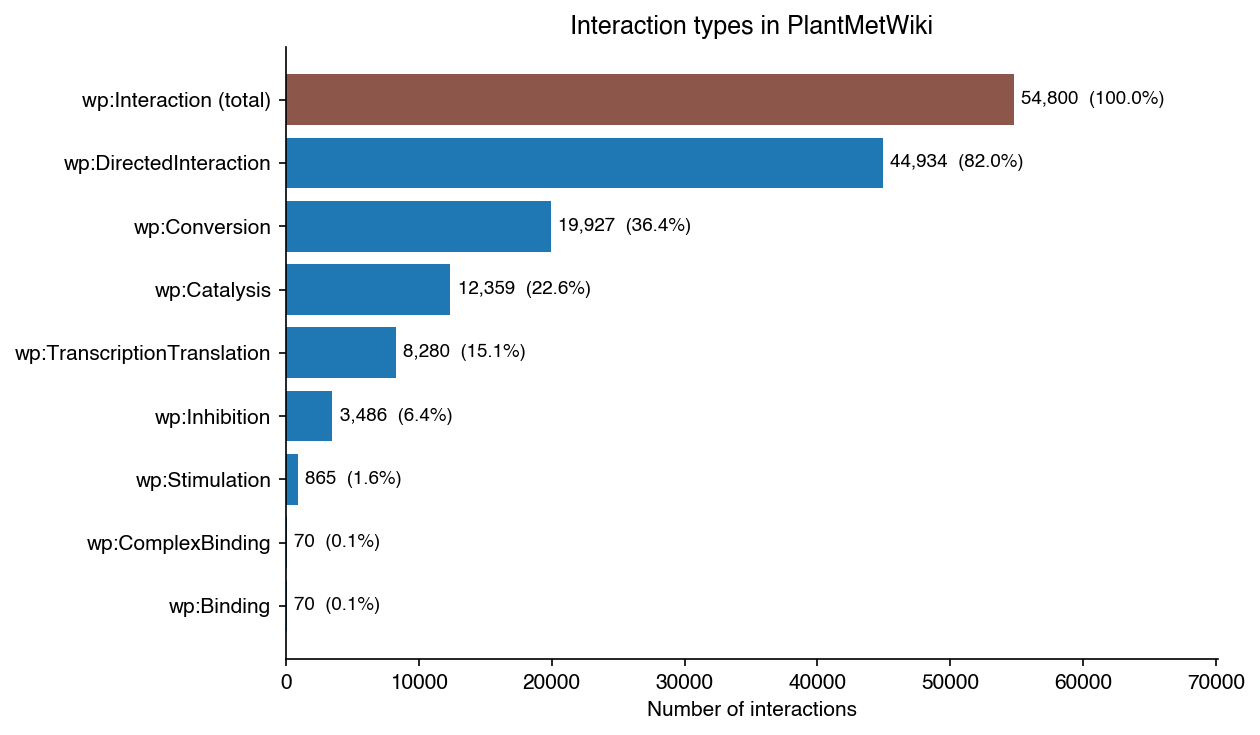

In [6]:
label_map = {
    "http://vocabularies.wikipathways.org/wp#DirectedInteraction":      "wp:DirectedInteraction",
    "http://vocabularies.wikipathways.org/wp#Conversion":               "wp:Conversion",
    "http://vocabularies.wikipathways.org/wp#Catalysis":                "wp:Catalysis",
    "http://vocabularies.wikipathways.org/wp#TranscriptionTranslation": "wp:TranscriptionTranslation",
    "http://vocabularies.wikipathways.org/wp#Inhibition":               "wp:Inhibition",
    "http://vocabularies.wikipathways.org/wp#Stimulation":              "wp:Stimulation",
    "http://vocabularies.wikipathways.org/wp#Binding":                  "wp:Binding",
    "http://vocabularies.wikipathways.org/wp#ComplexBinding":           "wp:ComplexBinding",
}
# int_types.csv matches *any* wp:-typed resource (a pre-existing quality of the
# underlying query), so restrict to genuine wp:Interaction sub-types here --
# entity/node types like wp:DataNode, wp:Metabolite, wp:Pathway are not
# interactions and must not appear in this figure.
sub = int_types[int_types["type"].isin(label_map.keys())].copy()
sub["label"] = sub["type"].map(label_map)
sub["pct"] = 100 * sub["n"] / total_interactions

total_row = pd.DataFrame([{"label": "wp:Interaction (total)", "n": total_interactions, "pct": 100.0}])
plot_df = pd.concat([sub[["label", "n", "pct"]], total_row], ignore_index=True)
plot_df = plot_df.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 5))
colors = ["#8c564b" if lbl == "wp:Interaction (total)" else "#1f77b4" for lbl in plot_df["label"]]
ax.barh(plot_df["label"], plot_df["n"], color=colors)
ax.set_xlabel("Number of interactions")
xmax = plot_df["n"].max()
for y, (n, pct) in enumerate(zip(plot_df["n"], plot_df["pct"])):
    ax.text(n + xmax * 0.01, y, f"{n:,}  ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlim(0, xmax * 1.28)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Interaction types in PlantMetWiki")
plt.tight_layout()
save_fig(fig, "plantmetwiki_interaction_types")
plt.show()


### Interpretation

The WikiPathways vocabulary (`wp:`) defines a type hierarchy for interactions.
Each edge in a pathway diagram is typed with one or more `wp:` classes.

| Type | What it represents |
|------|-------------------|
| **`wp:Interaction`** | Parent class — every interaction is an `Interaction`; count = total edges |
| **`wp:DirectedInteraction`** | A directed edge without further specification (e.g. transport, flow) |
| **`wp:Conversion`** | A biochemical transformation: substrate(s) → product(s). The core of metabolic pathways |
| **`wp:Catalysis`** | An enzyme → reaction link; always paired with a Conversion it catalyses |
| **`wp:TranscriptionTranslation`** | Gene → mRNA → protein relationships |
| **`wp:Inhibition`** | A negative regulatory effect on another node or reaction |
| **`wp:Stimulation`** | A positive regulatory or activating effect |
| **`wp:Binding`** / **`wp:ComplexBinding`** | Physical protein–protein or protein–compound interaction |
| **`wp:DataNode`**, **`wp:Metabolite`**, **`wp:Protein`**, **`wp:GeneProduct`**, **`wp:Pathway`** | Entity nodes typed in the same vocabulary; shown here because the SPARQL query matches any `wp:` class |

**Why Conversion and Catalysis dominate:**
PlantMetWiki is built from PlantCyc, a reaction-centric biochemistry database.
Every enzymatic step is represented as a `wp:Conversion` (the chemical reaction) plus one or more `wp:Catalysis` edges (each enzyme that catalyses it).
The near 1:1 ratio of Conversion to Catalysis reflects that most reactions have at least one curated enzyme.

**Why DirectedInteraction is large:**
Some PlantCyc pathway edges — particularly transport and regulatory links — are translated to `wp:DirectedInteraction` as a fallback type when no more specific class applies.

**Note:** The sub-figure A count (54,800 `wp:Interaction` instances) is the parent class total;
the B bars sum to more than this because many edges carry multiple sub-type labels simultaneously.


> **Figure caption -- Interaction type distribution.**
> Single panel: `wp:Interaction` (parent class total, brown bar) shown alongside each specific `wp:` interaction sub-type (WikiPathways vocabulary, `http://vocabularies.wikipathways.org/wp#`), so the total is directly comparable to its components rather than isolated in a separate panel.
> `wp:Conversion` = biochemical transformation (substrate -> product).
> `wp:Catalysis` = link from an enzyme (`wp:GeneProduct` or `wp:Protein`) to the reaction it catalyses.
> `wp:DirectedInteraction` = generic directed edge (used for transport, regulatory flow, etc.).
> `wp:TranscriptionTranslation` = gene -> transcript -> protein flow.
> `wp:Inhibition`, `wp:Stimulation` = negative/positive regulatory effects.
> `wp:Binding` / `wp:ComplexBinding` = physical interaction or complex formation.
> Sub-type counts sum to more than the `wp:Interaction (total)` bar because edges can carry multiple `wp:` type labels.


---
## 6. Figure: Species metrics — stacked bar (top 50)

  Saved -> figures/output/figures/plantmetwiki_species_metrics_stacked_top50.{pdf,svg}


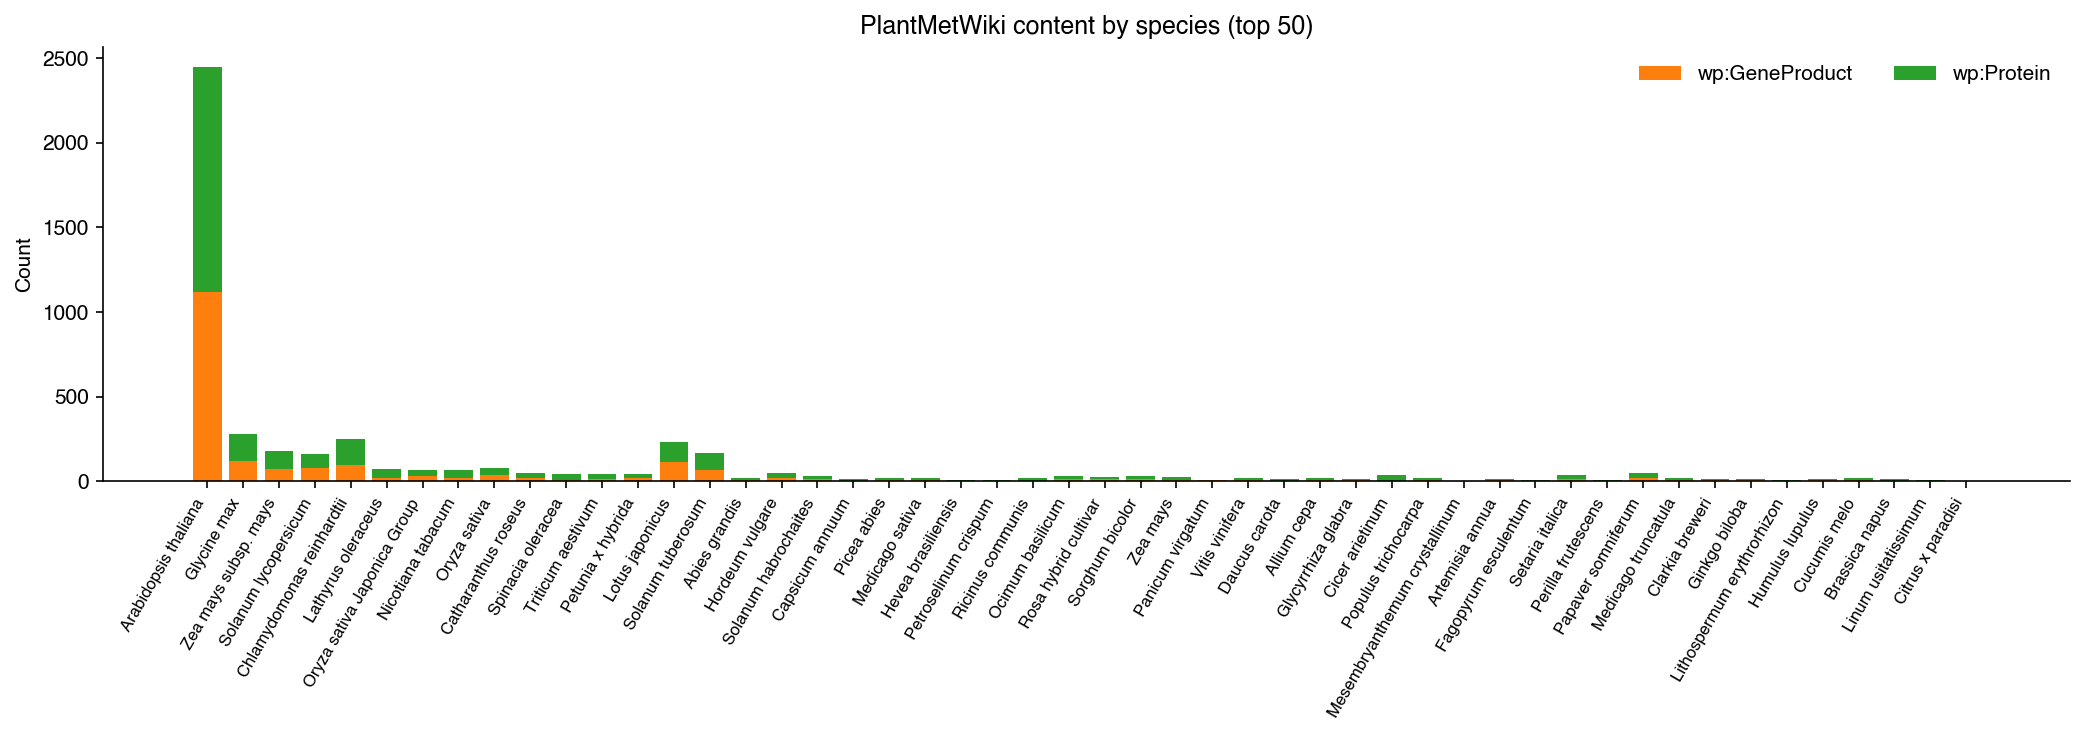

In [7]:
top50 = per_species.sort_values("pathways", ascending=False).head(50).copy()
stack_metrics = [c for c in ["genes", "enzymes"] if c in top50.columns]
COLORS = {"genes": "C1", "enzymes": "C2"}
LABELS = {"genes": "wp:GeneProduct", "enzymes": "wp:Protein"}

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(top50))
bottom = np.zeros(len(top50))
for m in stack_metrics:
    ax.bar(x, top50[m].values, bottom=bottom, label=LABELS[m], color=COLORS[m])
    bottom += top50[m].values
ax.set_xticks(x)
ax.set_xticklabels(top50["species"], rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax.set_title("PlantMetWiki content by species (top 50)")
ax.legend(ncol=2, frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save_fig(fig, "plantmetwiki_species_metrics_stacked_top50")
plt.show()


### Interpretation

Each bar shows the number of directly annotated **GeneProduct** (orange) and **Protein/enzyme** (green) nodes for the top 50 species by pathway count.

*Arabidopsis thaliana* dominates by a large margin because PlantCyc's reference database (AraCyc) is the most completely curated plant pathway collection.
The sharp drop after the top 5–10 species reflects the uneven curation depth across the PlantCyc species databases.

**Important caveat:** this figure shows *only* entities with a direct `wp:organism` triple.
Genes and proteins that lack a resolvable species annotation (~4 % and ~1 %, respectively; see Figure 3b) are excluded from these bars.
See Figure 6b for the extended view that adds metabolites, conversions, and publications via indirect pathway co-occurrence.


> **Figure caption — Species metrics, direct annotations (top 50).**
> Stacked bar chart for the 50 species with the most pathways, showing directly annotated entity counts per species.
> Species identity is encoded as `wp:organism ncbi:XXXXXX` (WikiPathways predicate, NCBITaxon IRI).
> Orange bars: `wp:GeneProduct` nodes tagged with a specific species (excluding the Viridiplantae root `ncbi:33090`).
> Green bars: `wp:Protein` (enzyme) nodes with a species tag.
> Species are ordered from left to right by decreasing pathway count (via `dcterms:isPartOf ?pw . ?pw a wp:Pathway`).


---
## 6b. Figure: Extended species metrics — indirect via shared pathway

Genes/enzymes are **directly** annotated with `wp:organism` in the taxonomy-extra graph.
Metabolites, conversions, and publications have **no direct species tag** — they are
attributed *indirectly* via shared pathway: if a gene of species X is in pathway P,
all metabolites, conversions, and publications in P are counted for species X.

  Saved -> figures/output/figures/plantmetwiki_species_combined_top50.{pdf,svg}


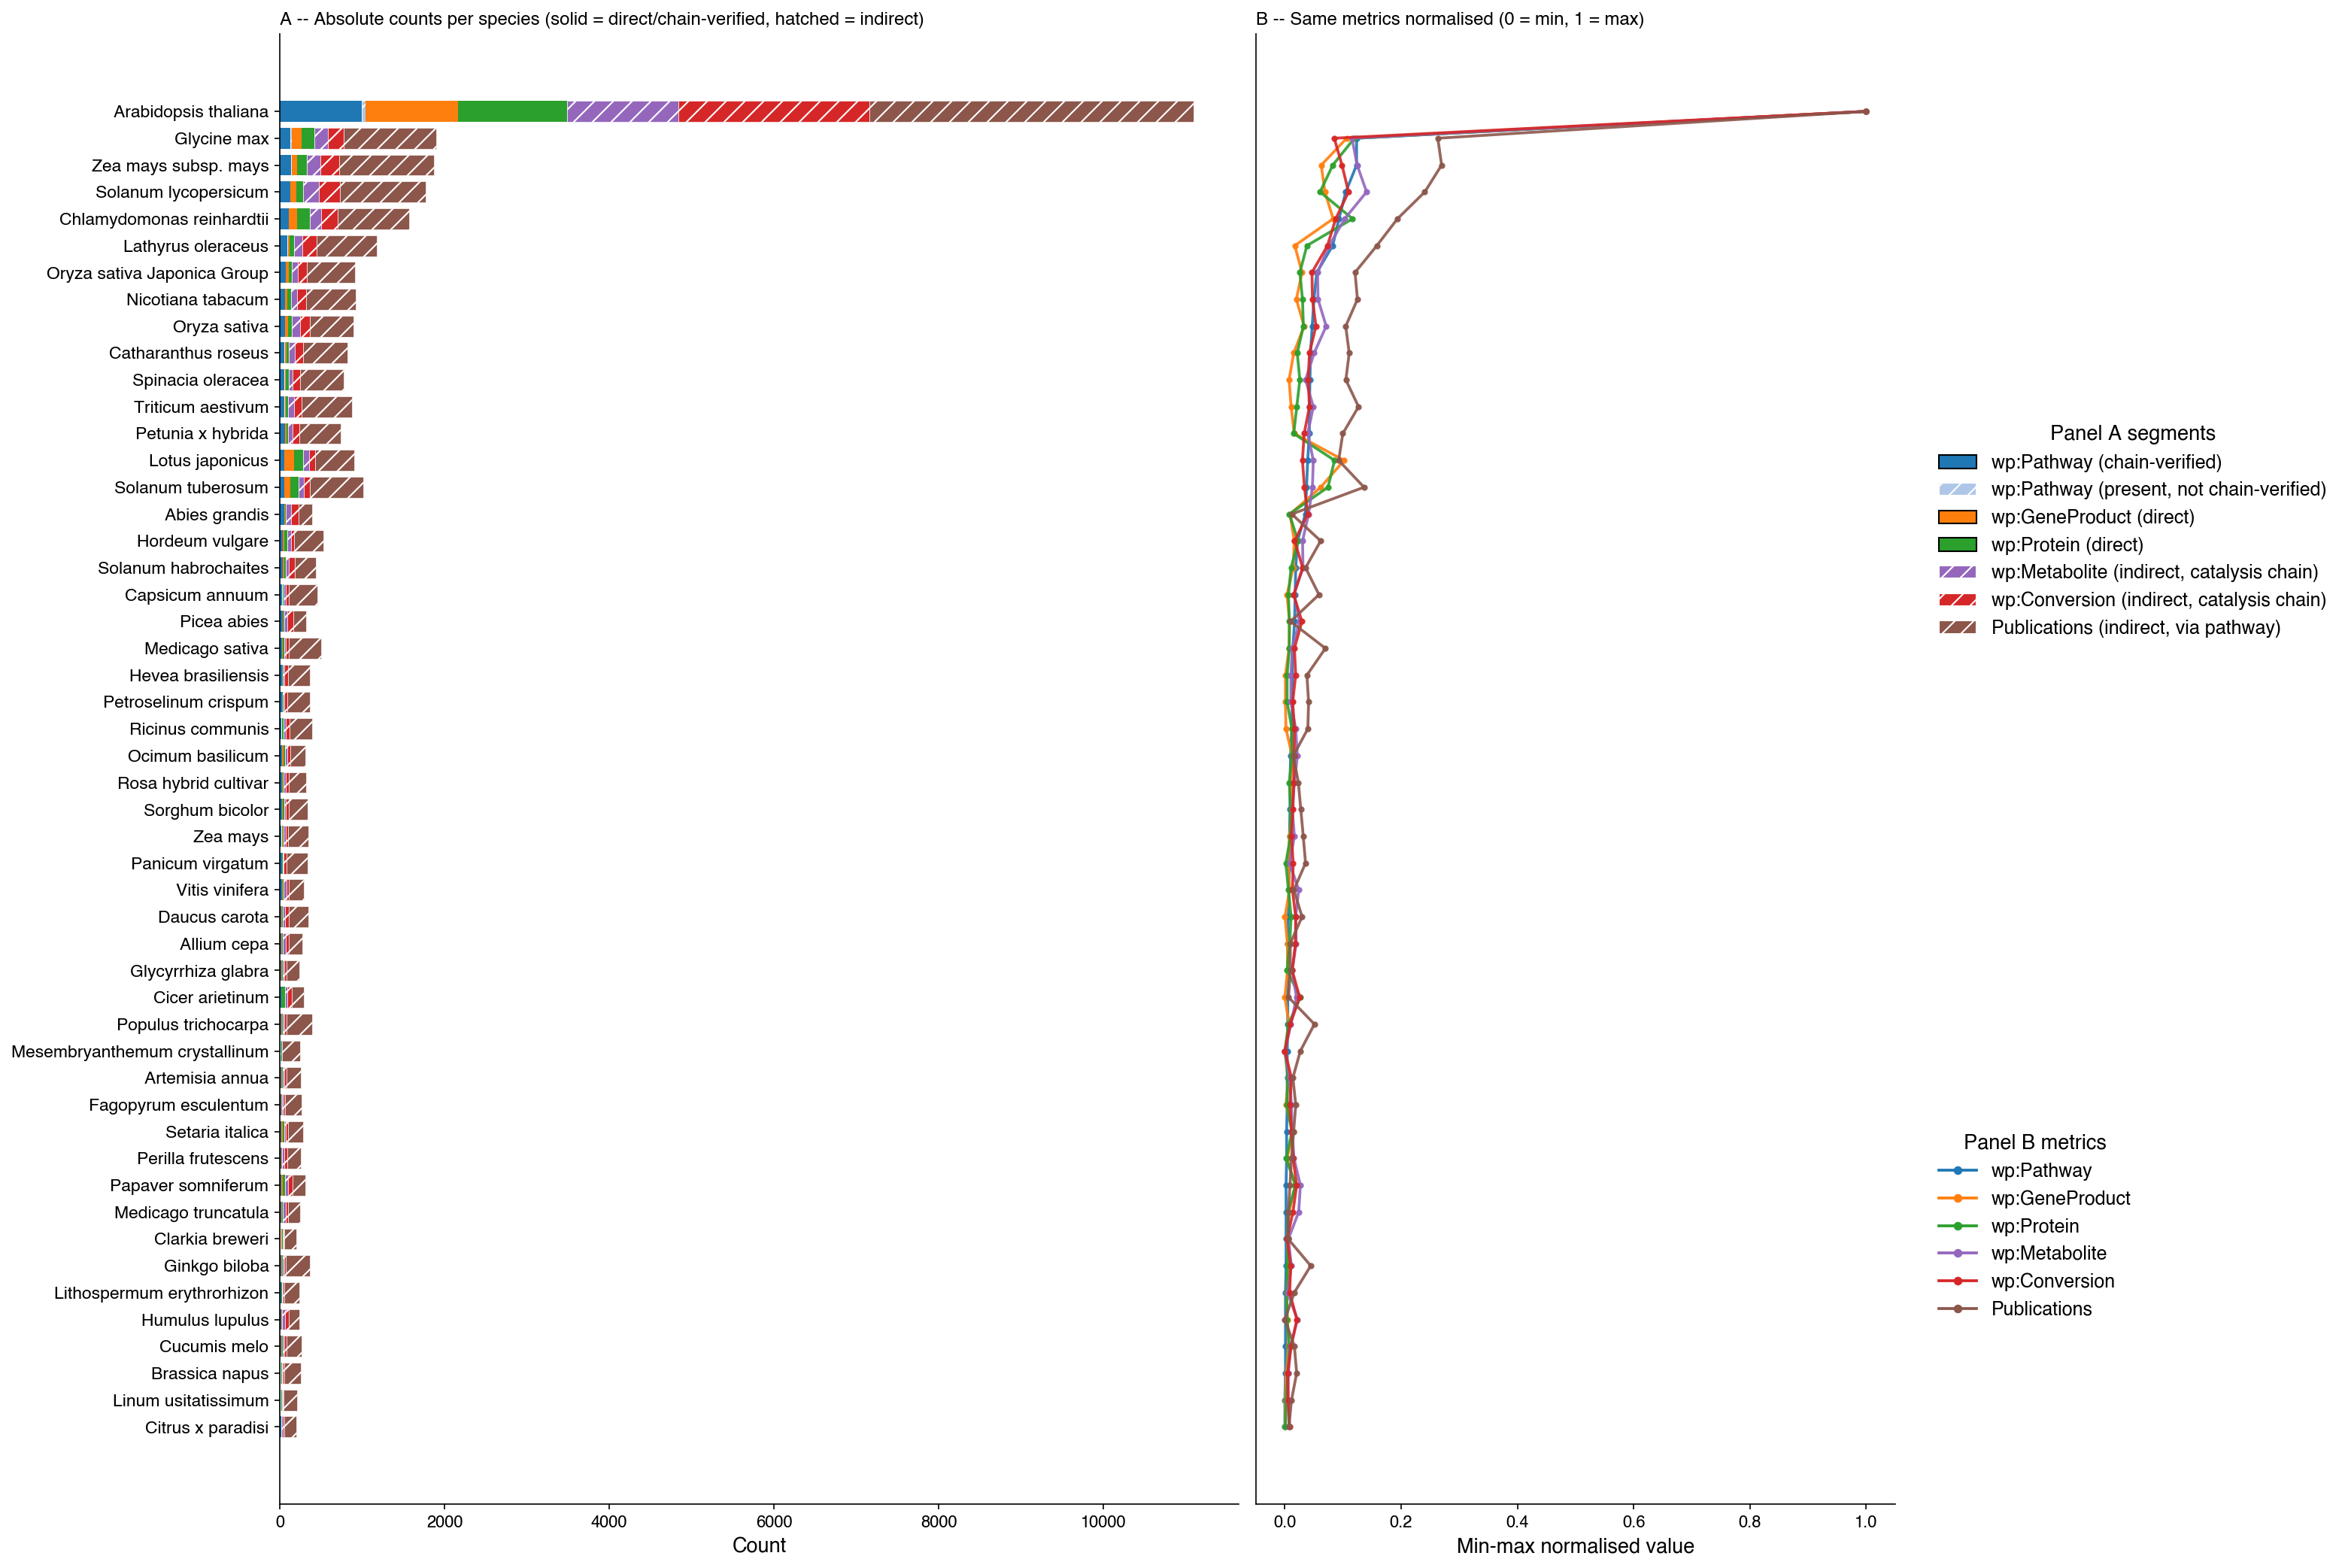

In [8]:
from matplotlib.patches import Patch

top50_ext = per_species.sort_values('pathways', ascending=False).head(50).copy()
for col in ['pathways', 'pathways_strict', 'pathways_indirect_extra', 'genes', 'enzymes',
            'metabolites', 'conversions', 'publications']:
    if col in top50_ext.columns:
        top50_ext[col] = pd.to_numeric(top50_ext[col], errors='coerce').fillna(0).astype(int)

# Reverse so the highest-pathway-count species ends up at the TOP of the
# horizontal chart (barh plots bottom-to-top by default).
top50_ext = top50_ext.iloc[::-1].reset_index(drop=True)
y = np.arange(len(top50_ext))

# (column, legend label, color, hatched?)
# "Direct" = wp:organism is on the entity itself.
# "Indirect, catalysis chain" = wp:Catalysis(entity) -> wp:Conversion -> wp:Metabolite,
#   i.e. only the specific reaction step(s) this species' enzyme actually
#   catalyses -- NOT every metabolite/conversion merely co-occurring in the
#   same pathway (see Figure 12 caption for the methodology change).
# wp:Pathway itself is split into the subset reachable via that same chain
# ("chain-verified", solid) vs. present per the broader direct gene/protein-
# in-pathway definition but not chain-verified ("indirect", hatched) -- e.g.
# regulatory/structural proteins not wired to a traced Catalysis step.
STACK = [
    ('pathways_strict',         'wp:Pathway (chain-verified)',                 '#1f77b4', False),
    ('pathways_indirect_extra', 'wp:Pathway (present, not chain-verified)',    '#aec7e8', True),
    ('genes',                   'wp:GeneProduct (direct)',                    '#ff7f0e', False),
    ('enzymes',                 'wp:Protein (direct)',                        '#2ca02c', False),
    ('metabolites',             'wp:Metabolite (indirect, catalysis chain)',  '#9467bd', True),
    ('conversions',             'wp:Conversion (indirect, catalysis chain)',  '#d62728', True),
    ('publications',            'Publications (indirect, via pathway)',       '#8c564b', True),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 14), sharey=True,
                                gridspec_kw={'width_ratios': [1.5, 1]})
fig.subplots_adjust(wspace=0.06)

# ── Panel A: stacked horizontal bars (vertical species list = legible, no rotated labels) ──
left = np.zeros(len(top50_ext))
legend_handles = []
for col, label, color, hatched in STACK:
    vals = top50_ext[col].values
    ax1.barh(y, vals, left=left, color=color, hatch='//' if hatched else None,
             edgecolor='white' if hatched else 'none', linewidth=0.3, height=0.78)
    left += vals
    legend_handles.append(Patch(facecolor=color, hatch=('//' if hatched else None),
                                 edgecolor='white' if hatched else 'black', label=label))

ax1.set_yticks(y)
ax1.set_yticklabels(top50_ext['species'], fontsize=11)
ax1.set_xlabel('Count', fontsize=13)
ax1.set_title('A -- Absolute counts per species (solid = direct/chain-verified, hatched = indirect)',
              fontsize=11.5, loc='left')
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='x', labelsize=10.5)

# ── Panel B: min-max normalised, same vertical species axis ─────────────────
all_metrics = ['pathways', 'genes', 'enzymes', 'metabolites', 'conversions', 'publications']
LINE_LABELS = {'pathways': 'wp:Pathway', 'genes': 'wp:GeneProduct', 'enzymes': 'wp:Protein',
               'metabolites': 'wp:Metabolite', 'conversions': 'wp:Conversion',
               'publications': 'Publications'}
LINE_COLS = {'pathways': '#1f77b4', 'genes': '#ff7f0e', 'enzymes': '#2ca02c',
             'metabolites': '#9467bd', 'conversions': '#d62728', 'publications': '#8c564b'}
line_handles = []
for m in all_metrics:
    vals = top50_ext[m].values.astype(float)
    mn, mx = vals.min(), vals.max()
    norm_vals = (vals - mn) / (mx - mn) if mx > mn else np.zeros_like(vals)
    line, = ax2.plot(norm_vals, y, color=LINE_COLS[m], linewidth=1.8,
                      marker='.', markersize=6, alpha=0.9)
    line_handles.append(Line2D([0], [0], color=LINE_COLS[m], marker='.', markersize=9,
                                linewidth=1.8, label=LINE_LABELS[m]))

ax2.set_xlabel('Min-max normalised value', fontsize=13)
ax2.set_title('B -- Same metrics normalised (0 = min, 1 = max)', fontsize=11.5, loc='left')
ax2.set_xlim(-0.05, 1.05)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='x', labelsize=10.5)
ax2.tick_params(axis='y', left=False)

# Shared legends as single, "rotated" (one entry per row, not multi-column
# horizontal rows) vertical lists at larger font, placed outside the axes.
fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.005, 0.66),
           ncol=1, frameon=False, fontsize=12, title='Panel A segments', title_fontsize=13)
fig.legend(handles=line_handles, loc='center left', bbox_to_anchor=(1.005, 0.22),
           ncol=1, frameon=False, fontsize=12, title='Panel B metrics', title_fontsize=13)

plt.tight_layout()
save_fig(fig, 'plantmetwiki_species_combined_top50')
plt.show()


### Interpretation

**Methodology change from the earlier version of this figure:** metabolites and conversions used to be attributed to a species if *any* gene of that species appeared *anywhere* in the same pathway -- which over-attributed, e.g., regulatory-step metabolites to species whose enzyme has nothing to do with that step. The indirect metrics now follow the actual reaction graph instead: species X's enzyme E must be `wp:source` of a `wp:Catalysis` whose `wp:target` is a specific `wp:Conversion` (genes are chained to their enzyme via `wp:TranscriptionTranslation` first); only that conversion and the metabolites it actually converts (`wp:source`/`wp:target`) count toward X.

For *Arabidopsis thaliana* (1,038 pathways total), this tightened definition gives:
- 995 pathways chain-verified (the enzyme is wired to a traced catalysis step), 43 only "present" (gene/protein in the pathway but not connected to a captured `wp:Catalysis` -- e.g. regulatory or structural roles)
- 1,354 metabolites and 2,323 conversions via the catalysis chain (down from the old pathway-co-occurrence figures of 2,597 and 12,092 -- the old numbers double-counted every reaction step in every Arabidopsis-touched pathway, not just the ones Arabidopsis enzymes catalyse)
- Publications stay pathway-level (3,929) since BioCyc citations are curated per pathway/reaction, not per reaction-step, so there's no finer chain to follow for them.

**Note on units:** Panel A stacks a *pathway count* (`wp:Pathway`, blue) together with *entity counts* (genes, enzymes, metabolites, conversions, publications) on the same axis for compact visual comparison across very different quantities -- treat the stacked total as a visual summary, not a single meaningful sum.


> **Figure caption -- Species metrics, extended/combined (top 50).**
> Both panels share the same vertical species axis (most pathway-rich at top), avoiding rotated category labels.
> **(A)** Absolute counts, horizontal stacked bars. Solid: `wp:GeneProduct`/`wp:Protein` with a direct `wp:organism` annotation, and the subset of `wp:Pathway` reachable via the catalysis chain below ("chain-verified"). Hatched: `wp:Metabolite` and `wp:Conversion` attributed indirectly via the specific `wp:Catalysis` chain (`wp:source`/`wp:target`) the species' enzyme participates in (not broad pathway co-occurrence -- see Interpretation above); publications via pathway-level `dcterms:references`/`cito:cites`; and the extra `wp:Pathway` count present per the broader direct gene/protein-in-pathway definition but not chain-verified.
> **(B)** Min-max normalisation (0 = minimum, 1 = maximum across the top 50 species) of: pathways, genes (`wp:GeneProduct`), enzymes (`wp:Protein`), metabolites (`wp:Metabolite`), conversions (`wp:Conversion`), and publications.


---
## 7. Figure: Scatter — genes vs metabolites (sized by species count)

  Saved -> figures/output/figures/scatter_genes_vs_metabolites_size_species.{pdf,svg}
Saved top_pathways_by_genes.csv


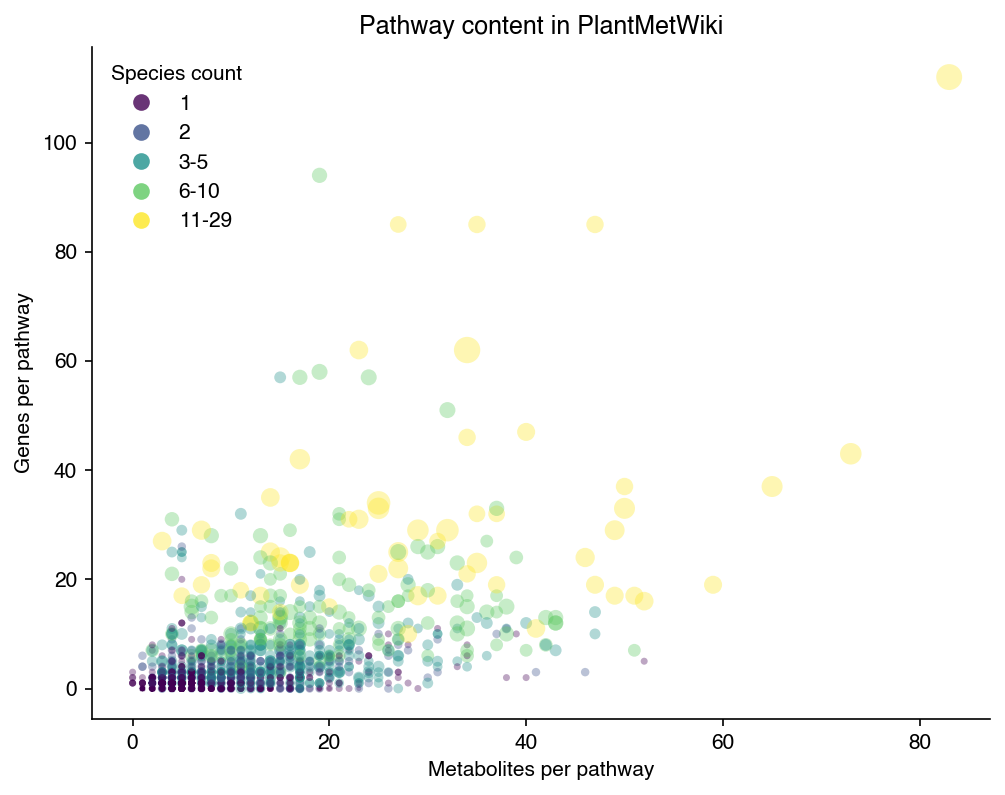

In [9]:
merged = metabolites[['pwID','metabolites']].merge(
    genes[['pwID','genes']], on='pwID', how='outer'
).merge(
    species_pw[['pwID','species']], on='pwID', how='outer'
).fillna(0)
merged = merged.merge(titles.rename(columns={'pwID':'pwID','title':'title'}),
                      on='pwID', how='left')
merged = merged[(merged['metabolites'] > 0) | (merged['genes'] > 0)].copy()
# Ensure species is numeric with no NaN
merged['species'] = pd.to_numeric(merged['species'], errors='coerce').fillna(0)

sp_min = int(merged['species'].min())
sp_max = int(merged['species'].max())
size = 6 + (merged['species'] - sp_min) / max(sp_max - sp_min, 1) * 154

bins   = sorted(set([0, 1, 2, 5, 10, max(10, sp_max)]))
blabels = [f"{bins[i-1]+1 if i>1 else 0}-{bins[i]}" if bins[i-1]+1 != bins[i]
           else str(bins[i]) for i in range(1, len(bins))]
merged['sp_bin']  = pd.cut(merged['species'], bins=bins, include_lowest=True,
                            right=True, labels=blabels)
merged['sp_code'] = merged['sp_bin'].cat.codes

fig, ax = plt.subplots(figsize=(6.8, 5.4))
ax.scatter(merged['metabolites'], merged['genes'],
           s=size, c=merged['sp_code'], cmap='viridis',
           alpha=0.35, edgecolors='none')
ax.set_xlabel('Metabolites per pathway')
ax.set_ylabel('Genes per pathway')
ax.set_title('Pathway content in PlantMetWiki')

cmap = plt.get_cmap('viridis')
norm_c = mpl.colors.Normalize(vmin=0, vmax=max(1, len(blabels)-1))
handles = [Line2D([0],[0], marker='o', linestyle='None',
                  markerfacecolor=cmap(norm_c(i)), markeredgecolor='none',
                  markersize=8, alpha=0.8) for i in range(len(blabels))]
ax.legend(handles, blabels, title='Species count', loc='best', frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'scatter_genes_vs_metabolites_size_species')

merged.sort_values(['genes','metabolites'], ascending=False)[
    ['pwID','title','genes','metabolites','species']
].head(50).to_csv(OUT_DIR / 'top_pathways_by_genes.csv', index=False)
print('Saved top_pathways_by_genes.csv')
plt.show()

### Interpretation

Each dot is one pathway or reaction object (2,478 total after outer-joining metabolites and genes).
**X-axis:** number of distinct metabolite nodes in that pathway.
**Y-axis:** number of distinct gene-product nodes.
**Dot size and colour (viridis):** number of annotated species — large/bright = multispecies pathway, small/dark = single-species or unannotated.

Most pathways cluster near the origin (few genes, few metabolites), representing individual enzymatic reactions (RC\* objects) or narrowly defined single-step pathways.
The sparse cloud toward the top-right contains large multispecies superpathways and central metabolic maps that are extensively curated across many species.

Pathways far to the right (many metabolites, few genes) tend to be compound-rich maps where metabolite nodes have been drawn but enzyme genes were not annotated.
Pathways far upward (many genes, few metabolites) often represent signalling or regulatory modules.


> **Figure caption — Pathway content scatter plot.**
> Each point is one `wp:Pathway` object (PC\* or RC\* IRI, 2,478 total).
> X-axis: count of distinct `wp:Metabolite` nodes (`dcterms:isPartOf` that pathway).
> Y-axis: count of distinct `wp:GeneProduct` nodes.
> Dot size and colour (viridis scale): number of distinct `wp:organism` taxon annotations (`ncbi:*`, excluding root `ncbi:33090`) pointing to nodes in that pathway.
> Large/bright = multispecies; small/dark = single-species or unannotated.


---
## 7b. Figure: Scatter with pathway labels for outliers

Labels the 15 most 'outlying' pathways — those furthest from the origin
(largest Euclidean distance from the point cloud centroid in genes–metabolites space).

  Saved -> figures/output/figures/scatter_outlying_pathways_labelled.{pdf,svg}


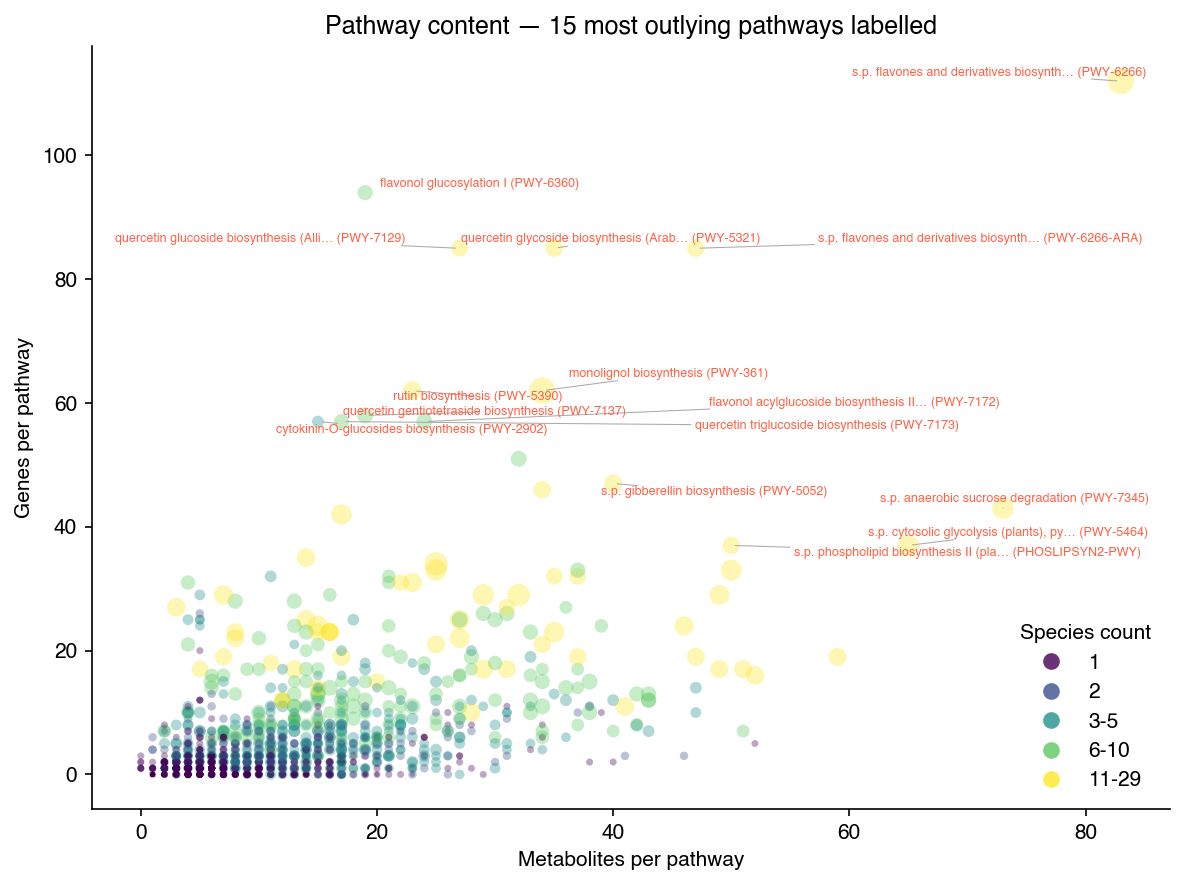

In [10]:
from adjustText import adjust_text

# Reuse merged from Figure 7 (rebuild if needed)
if 'merged' not in dir() or '_dist' not in merged.columns:
    merged = metabolites[['pwID','metabolites']].merge(
        genes[['pwID','genes']], on='pwID', how='outer'
    ).merge(species_pw[['pwID','species']], on='pwID', how='outer').fillna(0)
    merged = merged.merge(titles, on='pwID', how='left')
    merged = merged[(merged['metabolites'] > 0) | (merged['genes'] > 0)].copy()
    merged['species'] = pd.to_numeric(merged['species'], errors='coerce').fillna(0)

# Outlier score: Euclidean distance from centroid
cx, cy = merged['metabolites'].mean(), merged['genes'].mean()
merged['_dist'] = np.sqrt((merged['metabolites'] - cx)**2 + (merged['genes'] - cy)**2)
outliers = merged.nlargest(15, '_dist')

# ── Same size / colour encoding as Figure 7 ──────────────────────────────────
sp_min = int(merged['species'].min())
sp_max = int(merged['species'].max())
size   = 6 + (merged['species'] - sp_min) / max(sp_max - sp_min, 1) * 154

bins    = sorted(set([0, 1, 2, 5, 10, max(10, sp_max)]))
blabels = [f"{bins[i-1]+1 if i>1 else 0}-{bins[i]}" if bins[i-1]+1 != bins[i]
           else str(bins[i]) for i in range(1, len(bins))]
merged['sp_bin']  = pd.cut(merged['species'], bins=bins, include_lowest=True,
                            right=True, labels=blabels)
merged['sp_code'] = merged['sp_bin'].cat.codes

out_size = 6 + (outliers['species'] - sp_min) / max(sp_max - sp_min, 1) * 154

fig, ax = plt.subplots(figsize=(8, 6))

# All pathways — viridis by species count
ax.scatter(merged['metabolites'], merged['genes'],
           s=size, c=merged['sp_code'], cmap='viridis',
           alpha=0.35, edgecolors='none')

# Labels with adjustText — pathway title plus its PlantCyc PWY/RXN code in
# parentheses (e.g. "2-methylketone biosynthesis (PWY-6585)"), so each label
# is traceable back to the source PlantCyc database entry.
texts = []
for _, row in outliers.iterrows():
    label = str(row.get('title', row['pwID'])).replace('superpathway of ', 's.p. ')
    if len(label) > 40:
        label = label[:38] + '\u2026'
    pcid = row.get('pcid', '')
    if pd.notna(pcid) and str(pcid).strip():
        label = f"{label} ({pcid})"
    texts.append(ax.text(row['metabolites'], row['genes'], label,
                         fontsize=6, color='tomato'))
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.5))

# Species-count legend (same as Figure 7) + outlier entry
cmap   = plt.get_cmap('viridis')
norm_c = mpl.colors.Normalize(vmin=0, vmax=max(1, len(blabels)-1))
handles = [Line2D([0],[0], marker='o', linestyle='None',
                  markerfacecolor=cmap(norm_c(i)), markeredgecolor='none',
                  markersize=8, alpha=0.8) for i in range(len(blabels))]
ax.legend(handles, blabels, title='Species count', loc='best', frameon=False)

ax.set_xlabel('Metabolites per pathway')
ax.set_ylabel('Genes per pathway')
ax.set_title('Pathway content — 15 most outlying pathways labelled')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(fig, 'scatter_outlying_pathways_labelled')
plt.show()


### Interpretation

The 15 red-ringed pathways are the furthest from the centroid of the point cloud (Euclidean distance in genes–metabolites space) and therefore represent the most atypical content in PlantMetWiki.

They fall into two characteristic groups:

1. **Large superpathways** (top-right quadrant): contain many genes *and* many metabolites, typically because they aggregate several sub-pathways. These are the most information-dense objects in the resource.
2. **Compound-rich maps** (far right, few genes): metabolite nodes were imported from PlantCyc pathway diagrams but enzyme genes were not annotated — indicating gaps in the gene-to-reaction linkage.

Because these pathways pull in the most metabolites (and hence the most indirect species attributions via Figure 6b), they disproportionately shape species-level statistics.
Reviewers inspecting any single-species enrichment result should check whether the signal comes from one of these pathway giants.


> **Figure caption — Pathway content scatter plot with labelled outliers.**
> Same data and encoding as the scatter plot above.
> Red rings and labels mark the 15 `wp:Pathway` objects furthest from the point-cloud centroid (Euclidean distance in `wp:Metabolite` × `wp:GeneProduct` space).
> Each label shows the pathway title followed by its PlantCyc identifier in parentheses (`dcterms:identifier` in `graph/gpml-properties-extra`, e.g. "(PWY-6585)"), captured from the GPML `<Property key="UniqueID">` during conversion — this is the code to look up the same pathway directly in PlantCyc.
> These outliers include large superpathways (aggregating many sub-pathways via `dcterms:isPartOf`) and compound-rich maps where `wp:Metabolite` nodes were imported without corresponding `wp:GeneProduct` annotations.


---
## Sandbox